In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'font.family': 'sans-serif',
    'axes.titleweight': 'bold'
})

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
EXCEL_PATH = 'long_polar_with_CST.xlsx'
print(f"Loading {EXCEL_PATH} …")
raw = pd.read_excel(EXCEL_PATH)
AIRFOIL_COL = 'airfoil_name'
CST_COLS    = [c for c in raw.columns if c.startswith('cst_')]
ALPHA_COL   = 'alpha'
TARGET_COLS = ['CL', 'CD', 'CM']
EXTRA_FEAT  = ['Re']          

print(f"Raw shape : {raw.shape}")
print(f"CST cols  : {len(CST_COLS)}")
print(f"Targets   : {TARGET_COLS}")
raw.head()

Loading long_polar_with_CST.xlsx …
Raw shape : (129900, 31)
CST cols  : 18
Targets   : ['CL', 'CD', 'CM']


,airfoil_name,cst_0,cst_1,cst_2,cst_3,cst_4,cst_5,cst_6,cst_7,cst_8,...,logRe,CL,CD,CDp,CM,Chinge,Top_Xtr,Bot_Xtr,Cpmin,Xcpmin
0,2032c,-0.083089,0.008481,0.109397,0.159941,0.055176,0.167263,0.097558,0.128757,0.128834,...,5.30103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2032c,-0.083089,0.008481,0.109397,0.159941,0.055176,0.167263,0.097558,0.128757,0.128834,...,5.30103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2032c,-0.083089,0.008481,0.109397,0.159941,0.055176,0.167263,0.097558,0.128757,0.128834,...,5.30103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2032c,-0.083089,0.008481,0.109397,0.159941,0.055176,0.167263,0.097558,0.128757,0.128834,...,5.30103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2032c,-0.083089,0.008481,0.109397,0.159941,0.055176,0.167263,0.097558,0.128757,0.128834,...,5.30103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
keep_cols = [AIRFOIL_COL] + CST_COLS + [ALPHA_COL] + EXTRA_FEAT + TARGET_COLS
df = raw[keep_cols].dropna(subset=TARGET_COLS).reset_index(drop=True)

print(f"After dropping NaN targets: {df.shape[0]:,} rows  "
      f"({raw.shape[0] - df.shape[0]:,} removed)")
print(f"Unique airfoils           : {df[AIRFOIL_COL].nunique():,}")
df.describe().round(4)

After dropping NaN targets: 109,189 rows  (20,711 removed)
Unique airfoils           : 2,165


,cst_0,cst_1,cst_2,cst_3,cst_4,cst_5,cst_6,cst_7,cst_8,cst_9,...,cst_13,cst_14,cst_15,cst_16,cst_17,alpha,Re,CL,CD,CM
count,109189.0000,109189.0000,109189.0000,109189.0000,109189.0000,109189.0000,109189.0000,109189.0000,109189.0000,109189.0000,...,109189.0000,109189.0000,109189.0000,109189.0000,109189.0000,109189.0000,109189.0000,109189.0000,109189.0000,109189.0000
mean,-0.1379,-0.1184,-0.0506,-0.0934,-0.0504,-0.0597,-0.0307,0.0012,0.1702,0.2112,...,0.2302,0.1875,0.2046,0.1307,0.0017,4.4051,575535.0814,0.7352,0.0173,-0.0565
std,0.0611,0.1158,0.1536,0.1917,0.2059,0.1926,0.1327,0.1681,0.0729,0.1161,...,0.1856,0.1256,0.1601,0.2277,0.0059,5.4982,329968.9659,0.5692,0.0138,0.0523
min,-1.1553,-1.1346,-1.2722,-3.0775,-1.6606,-5.3183,-0.9813,-5.4766,0.0057,-0.7689,...,-0.7490,-2.7605,-0.3432,-1.5170,0.0000,-5.0000,200000.0000,-1.4694,0.0026,-0.4308
25%,-0.1610,-0.1729,-0.1164,-0.1823,-0.1318,-0.1291,-0.0917,-0.0753,0.1232,0.1400,...,0.1287,0.1222,0.1124,0.0046,0.0000,0.0000,200000.0000,0.2929,0.0090,-0.0864
50%,-0.1252,-0.1194,-0.0291,-0.1051,-0.0308,-0.0576,-0.0283,-0.0010,0.1528,0.1904,...,0.2017,0.1752,0.1871,0.1214,0.0001,4.0000,500000.0000,0.7926,0.0128,-0.0513
75%,-0.1015,-0.0667,0.0307,-0.0120,0.0473,0.0108,0.0281,0.0638,0.1987,0.2662,...,0.3012,0.2465,0.2695,0.2436,0.0019,9.0000,1000000.0000,1.1966,0.0205,-0.0177
max,-0.0112,0.4843,1.7229,1.1946,2.6865,1.6179,3.4012,1.6317,1.1553,1.0091,...,4.6396,1.1609,5.3076,2.6563,0.2408,14.0000,1000000.0000,2.8064,0.1946,0.1766


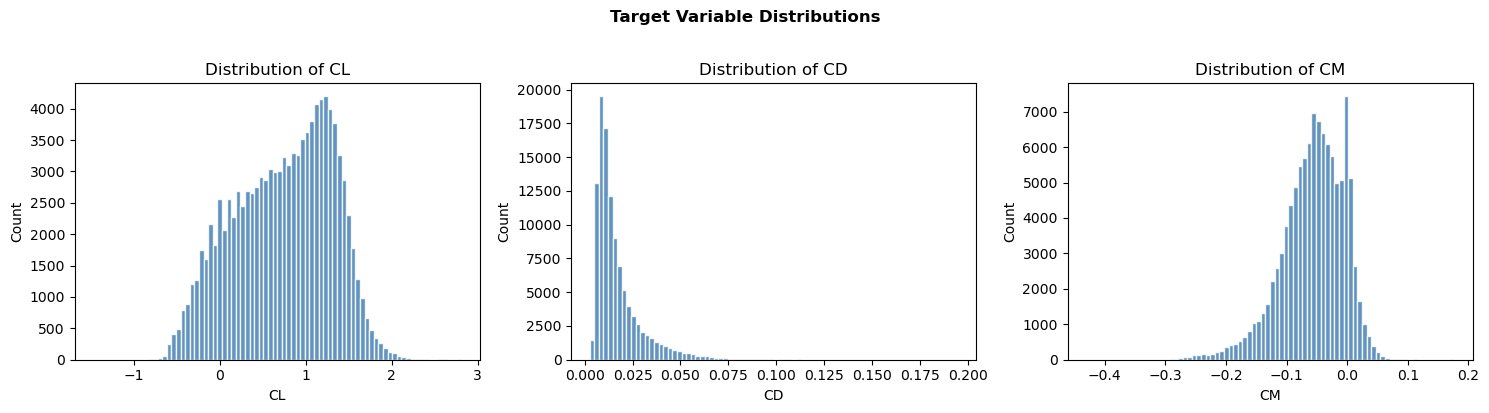

In [4]:
fig, axes = plt.subplots(1, len(TARGET_COLS), figsize=(5 * len(TARGET_COLS), 4))
if len(TARGET_COLS) == 1:
    axes = [axes]
for ax, col in zip(axes, TARGET_COLS):
    ax.hist(df[col], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {col}')
plt.suptitle('Target Variable Distributions', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

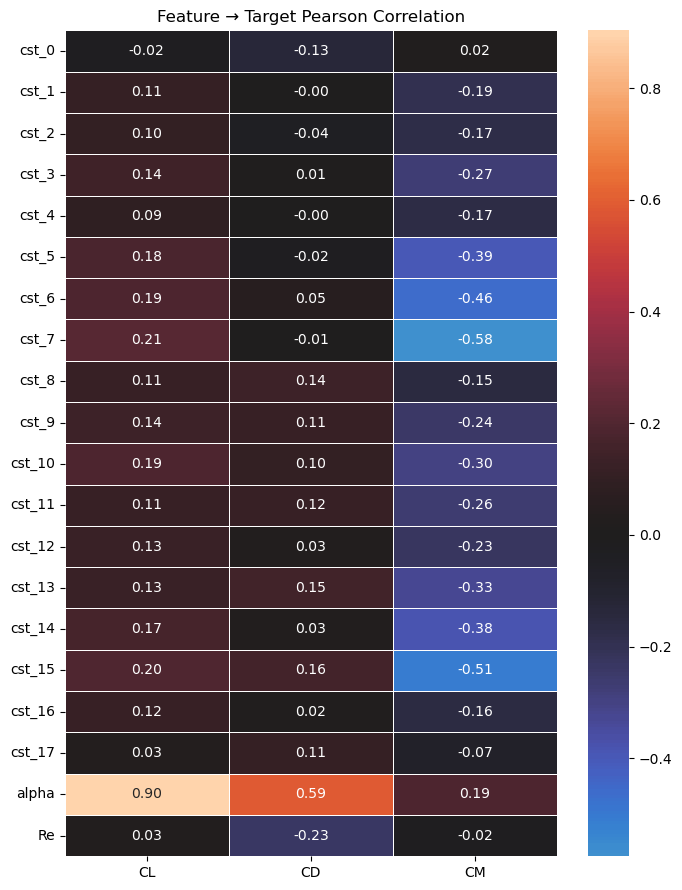

In [44]:
feat_cols = CST_COLS + [ALPHA_COL] + EXTRA_FEAT
corr = df[feat_cols + TARGET_COLS].corr()

corr_block = corr.loc[feat_cols, TARGET_COLS]

fig, ax = plt.subplots(
    figsize=(4 + len(TARGET_COLS), max(6, len(feat_cols) * 0.45))
)

sns.heatmap(
    corr_block,
    annot=True,
    fmt='.2f',
    center=0,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Feature → Target Pearson Correlation')

plt.tight_layout()
plt.show()

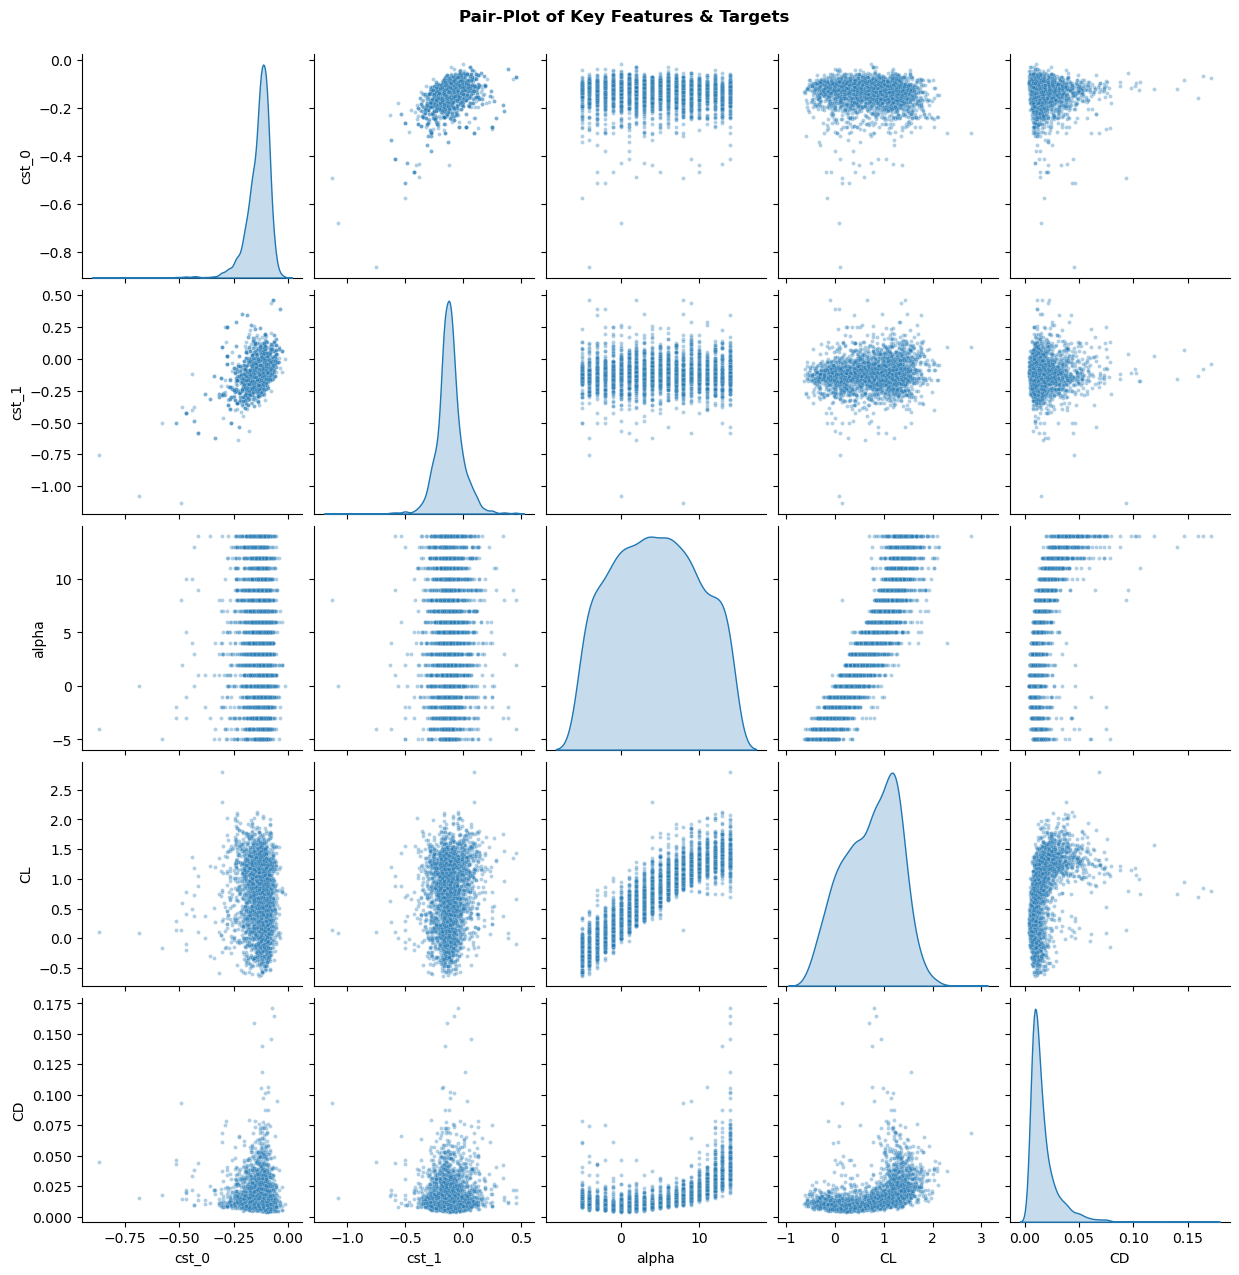

In [46]:
pair_cols = [CST_COLS[0], CST_COLS[1], ALPHA_COL, TARGET_COLS[0]]

if len(TARGET_COLS) > 1:
    pair_cols.append(TARGET_COLS[1])

sample_size = min(3000, len(df))
sample = df[pair_cols].sample(n=sample_size, random_state=SEED)

g = sns.pairplot(
    sample,
    diag_kind='kde',
    plot_kws={'s': 8, 'alpha': 0.35}
)

g.figure.suptitle(
    'Pair-Plot of Key Features & Targets',
    y=1.02,
    fontweight='bold'
)

plt.show()


In [ ]:
FEATURE_COLS = CST_COLS + [ALPHA_COL] + EXTRA_FEAT
X = df[FEATURE_COLS].values.astype(np.float32)
y = df[TARGET_COLS].values.astype(np.float32)
groups = df[AIRFOIL_COL].values      # group labels for splitting

print(f"Feature matrix X : {X.shape}")
print(f"Target  matrix y : {y.shape}")
print(f"Features         : {FEATURE_COLS}")

Feature matrix X : (109189, 20)
Target  matrix y : (109189, 3)
Features         : ['cst_0', 'cst_1', 'cst_2', 'cst_3', 'cst_4', 'cst_5', 'cst_6', 'cst_7', 'cst_8', 'cst_9', 'cst_10', 'cst_11', 'cst_12', 'cst_13', 'cst_14', 'cst_15', 'cst_16', 'cst_17', 'alpha', 'Re']


In [47]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

train_airfoils = set(groups[train_idx])
test_airfoils  = set(groups[test_idx])

print(f"Train : {X_train.shape[0]:>7,} rows  |  {len(train_airfoils):>5,} airfoils")
print(f"Test  : {X_test.shape[0]:>7,} rows  |  {len(test_airfoils):>5,} airfoils")
print(f"Overlap : {len(train_airfoils & test_airfoils)}")

Train :  87,405 rows  |  1,732 airfoils
Test  :  21,784 rows  |    433 airfoils
Overlap : 0


In [49]:
scaler_X = StandardScaler().fit(X_train)
X_train_s = scaler_X.transform(X_train)
X_test_s  = scaler_X.transform(X_test)

scaler_y = StandardScaler().fit(y_train)
y_train_s = scaler_y.transform(y_train)
y_test_s  = scaler_y.transform(y_test)

print("Scaling completed ")

Scaling completed 


In [50]:
sklearn_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree'    : DecisionTreeRegressor(max_depth=20, min_samples_leaf=5,
                                               random_state=SEED),
    'Random Forest'    : RandomForestRegressor(n_estimators=200, max_depth=25,
                                               min_samples_leaf=3, n_jobs=-1,
                                               random_state=SEED),
}
print('Scikit-learn models defined')

Scikit-learn models defined


In [12]:
class AirfoilNet(nn.Module):
    def __init__(self, in_dim: int, out_dim: int,
                 hidden: list[int] = [256, 256, 128, 64],
                 dropout: float = 0.10):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.SiLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


in_dim  = X_train_s.shape[1]
out_dim = y_train_s.shape[1]
model_nn = AirfoilNet(in_dim, out_dim).to(DEVICE)

print(model_nn)
total_params = sum(p.numel() for p in model_nn.parameters())
print(f"\nTotal parameters: {total_params:,}")

AirfoilNet(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): SiLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): SiLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): SiLU()
    (15): Dropout(p=0.1, inplace=False)
    (16): Linear(in_features=64, out_features=3, bias=True)
  )
)

Total parameters: 113,923


In [ ]:
sklearn_results = {}  

for name, mdl in sklearn_models.items():
    mdl.fit(X_train_s, y_train_s)

    y_pred_s = mdl.predict(X_test_s)
    y_pred = scaler_y.inverse_transform(y_pred_s)

    sklearn_results[name] = {
        'model'      : mdl,
        'y_pred'     : y_pred,
    }


In [ ]:
EPOCHS     = 150
BATCH_SIZE = 512
LR         = 1e-3
WD         = 1e-5

train_ds = TensorDataset(
    torch.from_numpy(X_train_s).float(),
    torch.from_numpy(y_train_s).float()
)
test_ds = TensorDataset(
    torch.from_numpy(X_test_s).float(),
    torch.from_numpy(y_test_s).float()
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=2048, shuffle=False)

optimiser = optim.AdamW(model_nn.parameters(), lr=LR, weight_decay=WD)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=EPOCHS)
criterion = nn.MSELoss()

print(f"Training for {EPOCHS} epochs  |  batch={BATCH_SIZE}  |  lr={LR}")

Training for 150 epochs  |  batch=512  |  lr=0.001


In [ ]:
history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, EPOCHS + 1):
    model_nn.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimiser.zero_grad()
        loss = criterion(model_nn(xb), yb)
        loss.backward()
        optimiser.step()
        running += loss.item() * xb.size(0)
    train_loss = running / len(train_ds)

    model_nn.eval()
    val_running = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_running += criterion(model_nn(xb), yb).item() * xb.size(0)
    val_loss = val_running / len(test_ds)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    scheduler.step()

    if epoch % 25 == 0 or epoch == 1:
        print(f"  Epoch {epoch:>4d}/{EPOCHS}  "
              f"train_loss={train_loss:.6f}  val_loss={val_loss:.6f}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}")

print(f"\nNeural Network training completed")

  Epoch    1/150  train_loss=0.166956  val_loss=0.095626  lr=1.00e-03
  Epoch   25/150  train_loss=0.050819  val_loss=0.051048  lr=9.33e-04
  Epoch   50/150  train_loss=0.042474  val_loss=0.046534  lr=7.50e-04
  Epoch   75/150  train_loss=0.037726  val_loss=0.042933  lr=5.00e-04
  Epoch  100/150  train_loss=0.034971  val_loss=0.039405  lr=2.50e-04
  Epoch  125/150  train_loss=0.033369  val_loss=0.037422  lr=6.70e-05
  Epoch  150/150  train_loss=0.031733  val_loss=0.037826  lr=0.00e+00

Neural Network training completed


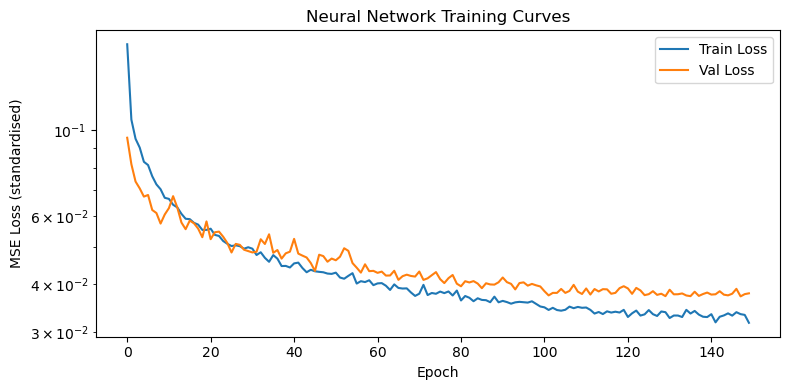

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history['train_loss'], label='Train Loss', linewidth=1.5)
ax.plot(history['val_loss'],   label='Val Loss',   linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss (standardised)')
ax.set_title('Neural Network Training Curves')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

In [51]:
model_nn.eval()

preds_nn_s = []

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(DEVICE)
        pred = model_nn(xb)
        preds_nn_s.append(pred.cpu().numpy())

preds_nn_s = np.vstack(preds_nn_s)

y_pred_nn = scaler_y.inverse_transform(preds_nn_s)

print("NN inference on", X_test_s.shape[0], "samples")

NN inference on 21784 samples


In [20]:
def compute_metrics(y_true, y_pred, target_names):
    """Return a DataFrame of per-target MSE, RMSE, MAE, R²."""
    rows = []
    for i, t in enumerate(target_names):
        mse  = mean_squared_error(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mse)
        mae  = mean_absolute_error(y_true[:, i], y_pred[:, i])
        r2   = r2_score(y_true[:, i], y_pred[:, i])
        rows.append({'Target': t, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R²': r2})
    return pd.DataFrame(rows)


all_results = {}
for name, res in sklearn_results.items():
    metrics_df = compute_metrics(y_test, res['y_pred'], TARGET_COLS)
    all_results[name] = {
        'metrics'    : metrics_df,
        'y_pred'     : res['y_pred'],
    }

nn_metrics = compute_metrics(y_test, y_pred_nn, TARGET_COLS)
all_results['Neural Network'] = {
    'metrics'    : nn_metrics,
    'y_pred'     : y_pred_nn,
}

print('Metrics computed for all models')

Metrics computed for all models


In [22]:
summary_rows = []
for model_name, res in all_results.items():
    for _, row in res['metrics'].iterrows():
        summary_rows.append({
            'Model'  : model_name,
            'Target' : row['Target'],
            'RMSE'   : row['RMSE'],
            'MAE'    : row['MAE'],
            'R²'     : row['R²'],
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.style.format({
    'RMSE': '{:.6f}',
    'MAE':  '{:.6f}',
    'R²':   '{:.4f}',
}).background_gradient(subset=['R²'], cmap='Greens')

,Model,Target,RMSE,MAE,R²
0,Linear Regression,CL,0.134015,0.093735,0.9446
1,Linear Regression,CD,0.010210,0.006612,0.4432
2,Linear Regression,CM,0.016485,0.011565,0.9049
3,Decision Tree,CL,0.142007,0.091780,0.9378
4,Decision Tree,CD,0.007698,0.003471,0.6835
5,Decision Tree,CM,0.024571,0.015761,0.7886
6,Random Forest,CL,0.107809,0.065294,0.9642
7,Random Forest,CD,0.005789,0.002544,0.8210
8,Random Forest,CM,0.018246,0.010934,0.8834
9,Neural Network,CL,0.054867,0.028739,0.9907


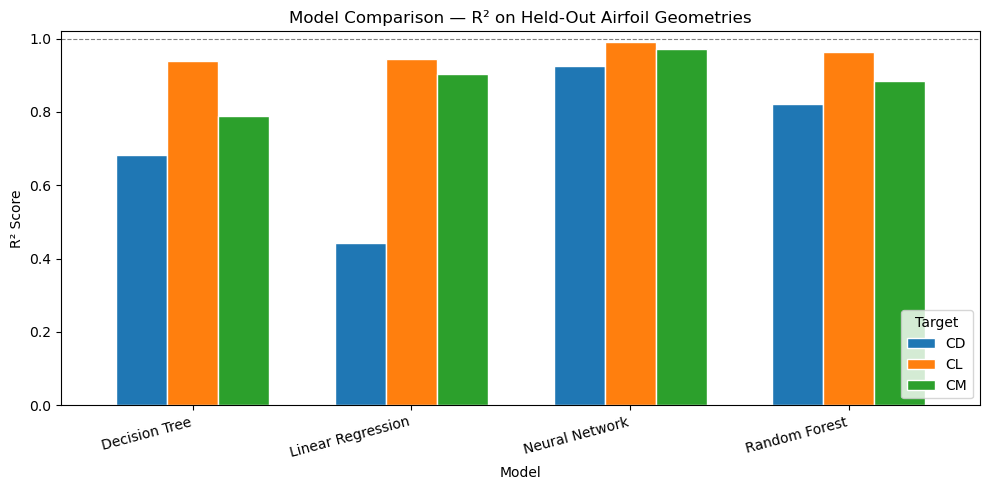

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
pivot = summary_df.pivot(index='Model', columns='Target', values='R²')
pivot.plot.bar(ax=ax, edgecolor='white', width=0.7)
ax.set_ylabel('R² Score')
ax.set_title('Model Comparison — R² on Held-Out Airfoil Geometries')
ax.set_ylim(min(0, pivot.min().min() - 0.05), 1.02)
ax.axhline(1.0, ls='--', color='grey', lw=0.8)
ax.legend(title='Target', loc='lower right')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

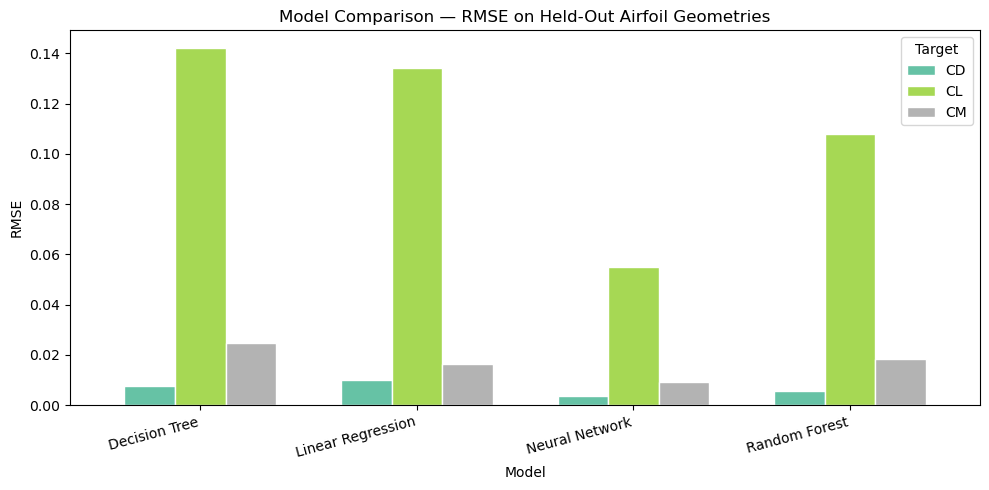

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
pivot_rmse = summary_df.pivot(index='Model', columns='Target', values='RMSE')
pivot_rmse.plot.bar(ax=ax, edgecolor='white', width=0.7, colormap='Set2')
ax.set_ylabel('RMSE')
ax.set_title('Model Comparison — RMSE on Held-Out Airfoil Geometries')
ax.legend(title='Target', loc='upper right')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

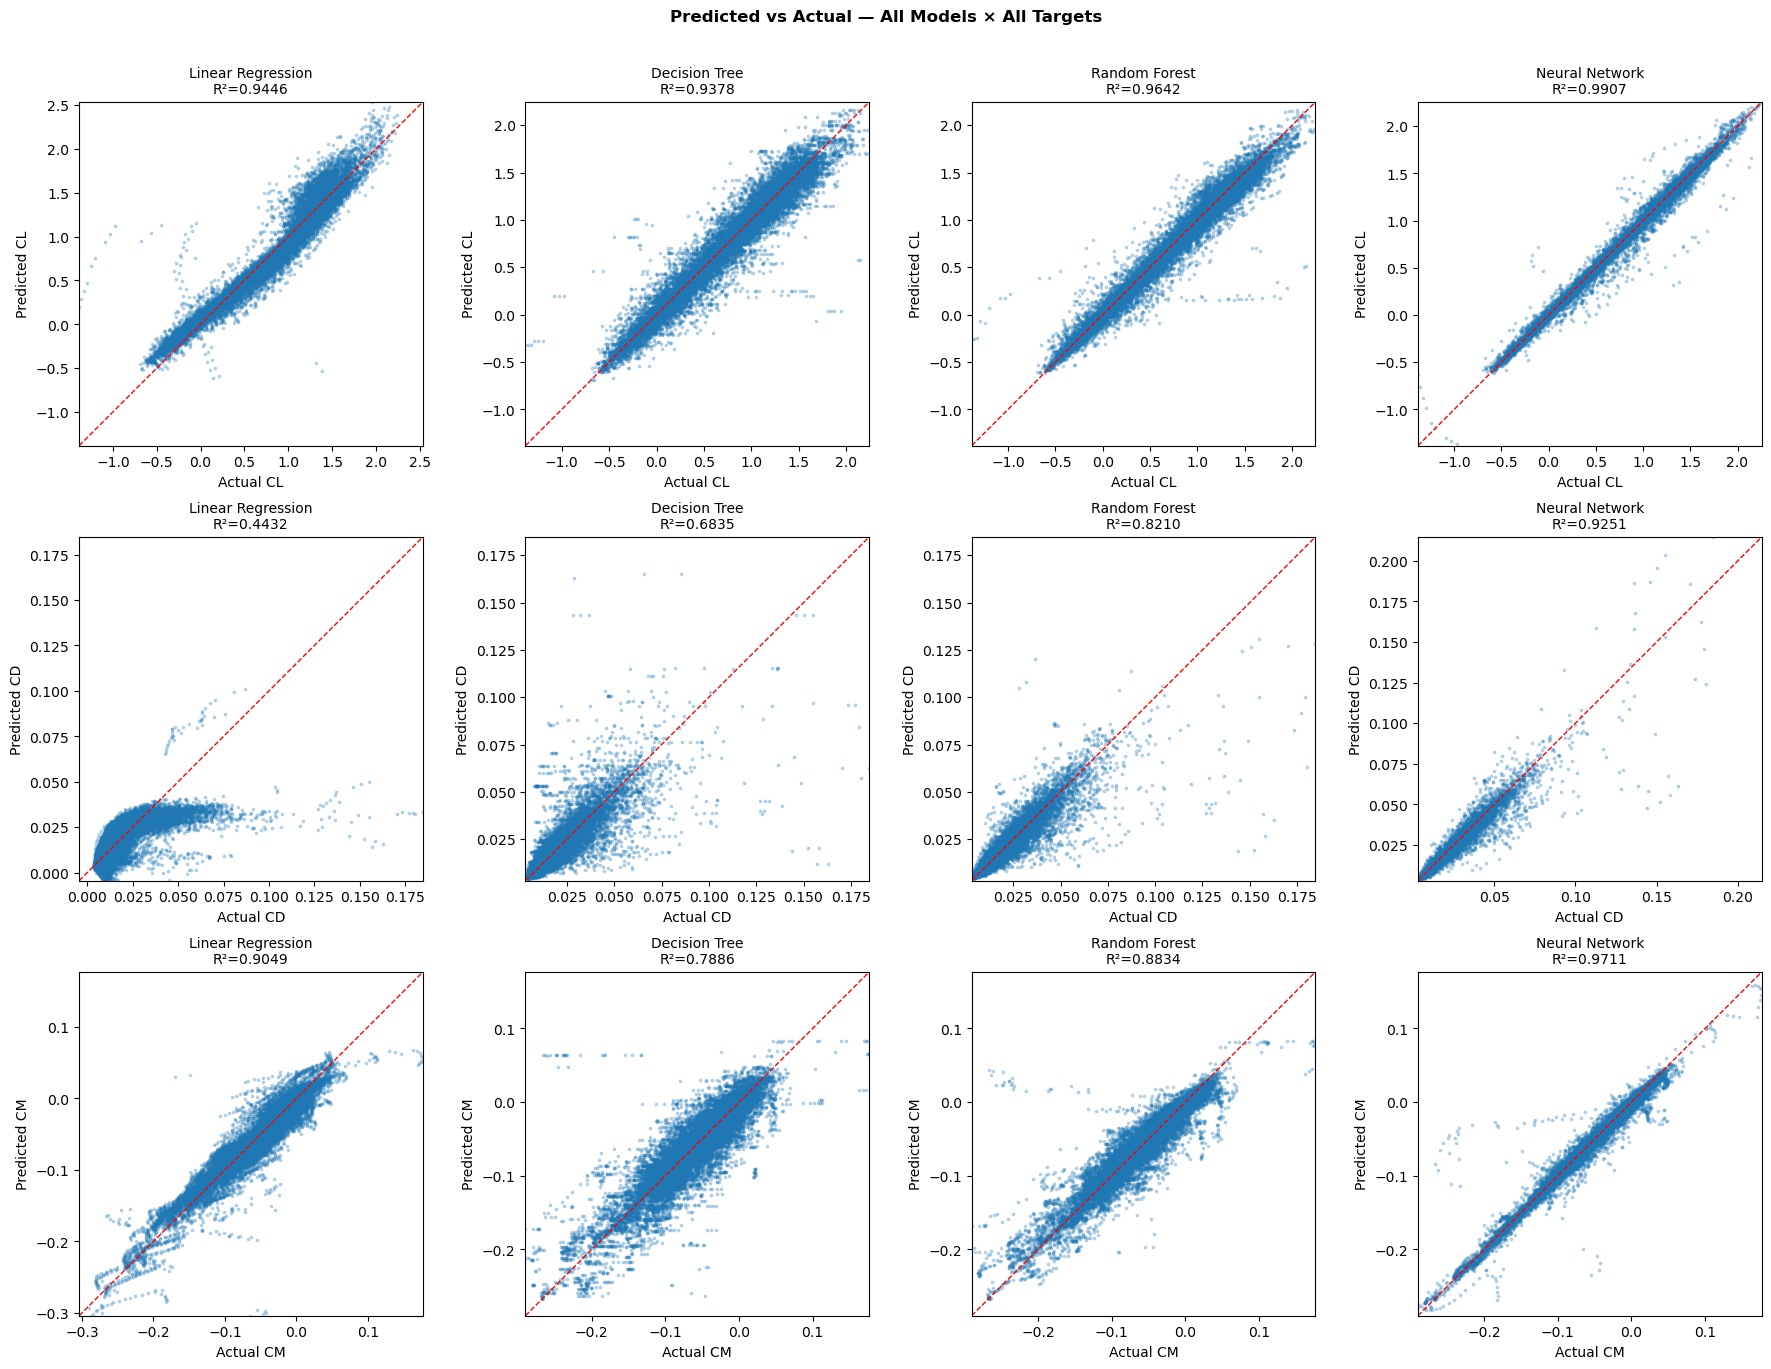

In [25]:
model_names = list(all_results.keys())
n_models  = len(model_names)
n_targets = len(TARGET_COLS)

fig, axes = plt.subplots(n_targets, n_models,
                         figsize=(4.5 * n_models, 4.5 * n_targets),
                         squeeze=False)

for j, tgt in enumerate(TARGET_COLS):
    for i, mname in enumerate(model_names):
        ax = axes[j, i]
        yp = all_results[mname]['y_pred'][:, j]
        yt = y_test[:, j]
        r2 = r2_score(yt, yp)

        ax.scatter(yt, yp, s=3, alpha=0.25, rasterized=True)
        lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
        ax.plot(lims, lims, 'r--', lw=1)
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel(f'Actual {tgt}')
        ax.set_ylabel(f'Predicted {tgt}')
        ax.set_title(f'{mname}\nR²={r2:.4f}', fontsize=10)
        ax.set_aspect('equal')

plt.suptitle('Predicted vs Actual — All Models × All Targets',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

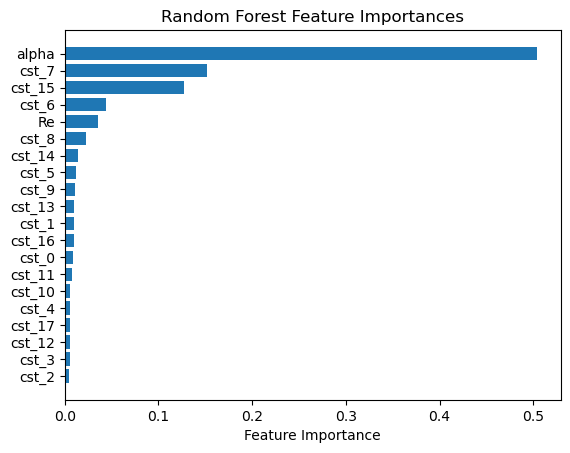

In [53]:
rf_model = sklearn_results['Random Forest']['model']
importances = rf_model.feature_importances_

imp_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': importances
}).sort_values('Importance')

plt.barh(imp_df['Feature'], imp_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importances')
plt.show()

In [54]:
import time
x_single = X_test_s[0:1]

timing_rows = []
for mname, res in sklearn_results.items():
    times = []
    for _ in range(500):
        t0 = time.perf_counter()
        _ = res['model'].predict(x_single)
        times.append(time.perf_counter() - t0)
    avg_us = np.mean(times) * 1e6
    timing_rows.append({'Model': mname, 'Single-sample (μs)': f'{avg_us:.1f}'})

x_t = torch.from_numpy(x_single).float().to(DEVICE)
model_nn.eval()
times_nn = []
for _ in range(500):
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = model_nn(x_t)
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    times_nn.append(time.perf_counter() - t0)
avg_us_nn = np.mean(times_nn) * 1e6
timing_rows.append({'Model': 'Neural Network', 'Single-sample (μs)': f'{avg_us_nn:.1f}'})

timing_df = pd.DataFrame(timing_rows)
print("\n Single-sample inference latency (averaged over 500 runs):")
timing_df


 Single-sample inference latency (averaged over 500 runs):


,Model,Single-sample (μs)
0,Linear Regression,58.6
1,Decision Tree,67.3
2,Random Forest,31339.1
3,Neural Network,529.9


In [ ]:
avg_r2 = {m: res['metrics']['R²'].mean() for m, res in all_results.items()}
best_name = max(avg_r2, key=avg_r2.get)
print(f"Best model: {best_name}  (avg R² = {avg_r2[best_name]:.4f})")

checkpoint = {
    'model_state_dict': model_nn.state_dict(),
    'scaler_X_mean'   : scaler_X.mean_,
    'scaler_X_scale'  : scaler_X.scale_,
    'scaler_y_mean'   : scaler_y.mean_,
    'scaler_y_scale'  : scaler_y.scale_,
    'feature_cols'    : FEATURE_COLS,
    'target_cols'     : TARGET_COLS,
    'architecture'    : str(model_nn),
}
torch.save(checkpoint, 'airfoil_surrogate_nn.pt')
print('Saved → airfoil_surrogate_nn.pt')

import joblib
joblib.dump(rf_model, 'airfoil_surrogate_rf.joblib')
print('Saved → airfoil_surrogate_rf.joblib')

Best model: Neural Network  (avg R² = 0.9623)
Saved → airfoil_surrogate_nn.pt
Saved → airfoil_surrogate_rf.joblib
